In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
GRID_SIZE = 5
GAMMA = 0.9

ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)

OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]

obstacle_through = True

ALPHA = 0.1
Epsilon = 0.1
max_episodes = 1000
max_steps = 100



In [20]:
"""
状态转移函数
"""

def step(state, action_idx, obstacle_through=False):
    """
    返回: next_state, reward
    """
    if state == GOAL_STATE:
        return state, 1.0
    
    # print(f"当前状态: {state}, 执行动作: {ACTION_SYMBOLS[action_idx]}")
    r, c = state
    dr, dc = ACTION[action_idx]
    next_r, next_c = r + dr, c + dc

    # 检查边界
    if next_r < 0 or next_r >= GRID_SIZE or next_c < 0 or next_c >= GRID_SIZE:
        return state, -1.0 # 撞墙: 奖励-1，留在原地
    
    next_state = (next_r, next_c)

    # 检查障碍物
    if obstacle_through:
        if next_state in OBSTACLE:
            return next_state, -10.0
    else:
        if next_state in OBSTACLE:
            return state, -10.0 # 撞障碍物: 奖励-10，留在原地; 如果允许穿过障碍物，则为返回next_state
    
    # 正常状态转移
    if next_state == GOAL_STATE:
        return next_state, 1.0 # 到达目标状态: 奖励1
    else:
        return next_state, -0.1

"""
提取最优策略 (Policy Extraction)
"""
def extract_policy(GRID_SIZE, OBSTACLE, Q_final, obstacle_through=True):
    final_policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    final_V = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if (i, j) in OBSTACLE and not obstacle_through:
                continue 
            
            # 提取最大 Q 值对应的动作 (argmax)
            final_policy[i, j] = np.argmax(Q_final[i, j])
            # 提取最大 Q 值作为该格子的状态价值 V(s) (max)
            final_V[i, j] = np.max(Q_final[i, j])
    
    return final_policy, final_V
    

In [21]:
"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, Epsilon, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 只有在不允许穿透时，才把障碍物设为 NaN 挖空（显示为背景色）
    # 如果允许穿透，我们要保留它惨烈的负分，让热力图显示出来
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if not obstacle_through and state in OBSTACLE:
                # 不可穿透的墙，画上灰色大方块
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            
            elif state == GOAL_STATE:
                # 终点
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                
                # 如果允许穿透，给障碍物格子加上特殊的色和紫色箭头
                if obstacle_through and state in OBSTACLE:
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='purple', fontsize=18, weight='bold')
                    ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='red', alpha=0.3, fontsize=20)
                else:
                    # 正常平地
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='black', fontsize=16, weight='bold')
                
    plt.title(f"MC Control ($\gamma$={GAMMA}, $\epsilon$={Epsilon}) | Obstacle Through: {obstacle_through}")
    plt.show()

def plot_learning_curve(learning_curve, window_size=100):
    """
    繪製學習曲線，包含原始回報和滑動平均回報
    """
    plt.figure(figsize=(10, 6))
    
    # 1. 繪製原始數據 (淺藍色，透明度低，用於觀察波動範圍)
    plt.plot(learning_curve, color='blue', alpha=0.2, label='Raw Total Reward')
    
    # 2. 計算並繪製滑動平均線 (紅色，較粗，用於觀察收斂趨勢)
    # 只有當 episode 數量大於窗口大小時才計算
    if len(learning_curve) >= window_size:
        # 使用 np.convolve 快速計算滑動平均
        moving_avg = np.convolve(learning_curve, np.ones(window_size)/window_size, mode='valid')
        # x 軸需要對齊，因為 valid 模式會砍掉前面的 window_size - 1 個點
        x_axis = np.arange(window_size - 1, len(learning_curve))
        plt.plot(x_axis, moving_avg, color='red', linewidth=2.5, label=f'Moving Average')
        
    plt.title('Monte Carlo Control Learning Curve', fontsize=16)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Total Reward per Episode', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()



In [22]:
"""
epsilon-greedy 策略
"""
def get_epsilon_greedy_action(q_value, epsilon):
    if np.random.rand() < epsilon:
        # 探索: 以 epsilon 的概率随机选择一个动作
        return np.random.randint(len(q_value))  # 随机选择一个动作
    else:
        return np.argmax(q_value)

In [23]:
"""
Sarsa (On policy TD control)  用到了(s_t, a_t, r_{t+1}, s_{t+1}, a_{t+1})五元组进行更新
Update Q value: q_{t+1}(s_t, a_t) = q_t(s_t, a_t) - alpha_t(s_t, a_t)*[q_t(s_t, a_t) - [r_{t+1} + gamma*q_t(s_{t+1}, a_{t+1})]]
Update policy: epsilon-greedy 
"""
def Sarsa(Q, Epsilon, GRID_SIZE, GOAL_STATE, OBSTACLE, GAMMA, ALPHA, max_steps, num_episodes, obstacle_through=False):
    # 记录每个 Episode 的总回报，用于画学习曲线
    return_history = []

    for episode in range(num_episodes):
        
        while True:
            # 随机初始化一个合法的起点 S
            r = np.random.randint(GRID_SIZE)
            c = np.random.randint(GRID_SIZE)
            state = (r, c)

            if state == GOAL_STATE:
                continue
            if not obstacle_through and state in OBSTACLE:
                continue
            break

        # 在起点根据 epsilon-greedy 策略选择一个动作 A
        action = get_epsilon_greedy_action(Q[r, c], Epsilon)

        episode_total_reward = 0.0

        for _step in range(max_steps):
            # 执行动作，观察到即时奖励 R 和下一个状态 S'
            next_state, reward = step(state, action, obstacle_through)
            episode_total_reward += reward

            # 在下一个状态 S' 根据 epsilon-greedy 策略选择下一个动作 A'
            # 下一步的值为估计的 Q(S', A')，而并没有直接使用环境返回的奖励 R 来更新 Q(S, A)，这是 Sarsa 的核心所在
            if next_state == GOAL_STATE:
                next_q_value = 0.0
                next_action = None
            else:
                next_action = get_epsilon_greedy_action(Q[next_state], Epsilon)
                next_q_value = Q[next_state][next_action]

            # 更新 Q(S, A), policy evluationb
            r, c = state
            current_q = Q[r, c, action]

            TD_target = reward + GAMMA * next_q_value
            TD_error = current_q - TD_target

            Q[r, c, action] -= ALPHA * TD_error

            # 如S'为终止状态，则跳出循环
            if next_state == GOAL_STATE:
                break

            state = next_state
            action = next_action

        return_history.append(episode_total_reward)
    
    return Q, return_history


In [24]:
"""
Expected Sarsa (On policy TD control)  用到了(s_t, a_t, r_{t+1}, s_{t+1})四元组进行更新
Update Q value: q_{t+1}(s_t, a_t) = q_t(s_t, a_t) - alpha_t(s_t, a_t)*[q_t(s_t, a_t)-[r_{t+1} + gamma*E[q_t(S_{t+1}, A)]]]
Update policy: epsilon-greedy
"""
def Expected_Sarsa(Q, Epsilon, ALPHA, GAMMA, GRID_SIZE, GOAL_STATE, OBSTACLE, max_steps, num_episodes, obstacle_through=False):

    return_history = []
    num_actions = len(ACTION)

    for episode in range(num_episodes):
        # 随机初始化一个合法的起点 S
        while True:
            r = np.random.randint(GRID_SIZE)
            c = np.random.randint(GRID_SIZE)
            state = (r, c)

            if state == GOAL_STATE:
                continue
            if not obstacle_through and state in OBSTACLE:
                continue
            break

        # 在起点根据 epsilon-greedy 策略选择一个动作 A
        action = get_epsilon_greedy_action(Q[r, c], Epsilon)
        episode_total_reward = 0.0

        for _ in range(max_steps):
            
            # 执行动作，观察到即时奖励 R 和下一个状态 S'
            next_state, reward = step(state, action, obstacle_through)
            episode_total_reward += reward

            # 计算下一步的期望 Q 值
            if next_state == GOAL_STATE:
                expected_q = 0.0
                next_action = None
            else: 
                next_q_values = Q[next_state]
                best_next_action = np.argmax(next_q_values)

                # 计算 epsilon-greedy 策略下每个动作被选中的概率
                # 所有动作最少有 epsilon / num_actions 的概率被选中，最优动作额外有 (1 - epsilon) 的概率被选中
                action_probs = np.ones(num_actions) * (Epsilon / num_actions)
                action_probs[best_next_action] += (1.0 - Epsilon)

                expected_q = np.sum(action_probs * next_q_values)

                # 仍然需要根据 epsilon-greedy 策略选择一个动作来计算期望 Q 值
                # 虽然用“期望值”更新了 Q 表，但机器人在环境里真实要走的下一步，还是要抽样决定
                next_action = get_epsilon_greedy_action(next_q_values, Epsilon)

            # 更新 Q(S, A), policy evaluation
            r, c = state
            current_q = Q[r, c, action]
            
            TD_target = reward + GAMMA * expected_q
            TD_error = current_q - TD_target

            Q[r, c, action] -= ALPHA * TD_error

            if next_state == GOAL_STATE:
                break

            state = next_state
            action = next_action

        return_history.append(episode_total_reward)
    return Q, return_history


In [25]:
"""
N-steps Sarsa (On policy TD control)  用到了(s_t, a_t, r_{t+1}, s_{t+2}, ..., s_{t+n})多元组进行更新
Update Q value: q_{t+n}(s_t, a_t) = q_t(s_t, a_t) - alpha_t(s_t, a_t)*[q_t(s_t, a_t) - [r_{t+1} + gamma*r_{t+2} + ... + gamma^{n-1}*r_{t+n} + gamma^n*q_t(S_{t+n}, A_{t+n})]]
Update policy: epsilon-greedy


"""

def n_step_Sarsa(Q, Epsilon, num_episodes, GRID_SIZE, GOAL_STATE, OBSTACLE, GAMMA, ALPHA, n_steps, max_steps, obstacle_through=False):

    return_history = []
    num_actions = len(ACTION)

    for episode in range(num_episodes):
        # 随机初始化一个合法的起点 S
        while True:
            r = np.random.randint(GRID_SIZE)
            c = np.random.randint(GRID_SIZE)
            state = (r, c)

            if state == GOAL_STATE:
                continue
            if not obstacle_through and state in OBSTACLE:
                continue
            break

        action = get_epsilon_greedy_action(Q[r, c], Epsilon)

        # 建立记忆 Buffer 存储轨迹
        states = [state]
        actions = [action]
        rewards = [0.0] # reward 的索引从 1 开始，reward[0] 是占位符，不使用

        T = float('inf') # 记录结束的真实时间步
        t = 0            # 当前机器人的时间步
        episode_total_reward = 0.0
        """
        假设 n=3, 机器人在第 7 步撞到了终点(T=7)
        此时, 机器人身体停下, 但大脑才更新到第4步的 Q 值 (因为 7 - 3 = 4). 
        但是后续的 5 步、6 步的 Q 值还需要更新! 因此, 代码里的逻辑：当 t >= T 时, 机器人不走了(不再执行 step 函数，不再 append 新状态)
        但是 while True 循环并没有停止! tau 会继续增加，把残留在 Buffer 里的第 5 步、第 6 步依次掏出来更新。
        因为此时 (tau + n_{steps}) >= T, 代码会自动跳过 + \gamma^n Q 的boostrapping部分, 纯靠真实的终止奖励来更新这些末尾的状态.
        直到 tau == T - 1 (第 6 步也被更新完), 循环才会被 break 打破
        """
        while True:
            # 如果 t < T，说明机器人还没有真正结束，那么继续执行动作并记录轨迹
            if t < T:
                next_state, reward = step(states[t], actions[t], obstacle_through)
                episode_total_reward += reward

                states.append(next_state)
                rewards.append(reward)

                # 检查是否到达终点或最大步数
                if next_state == GOAL_STATE or t+1 >= max_steps:
                    T = t + 1
                else:
                    next_action = get_epsilon_greedy_action(Q[next_state], Epsilon)
                    actions.append(next_action)

            
            # tau 是当前大脑正在更新的过去状态的时间步
            # 只有当机器人走到第 n 步，才开始更新
            tau = t - n_steps + 1

            if tau >= 0:
                # 计算 n 步的discounted return G
                G = 0.0
                for i in range(tau+1, min(tau + n_steps, T) + 1):
                    G += (GAMMA ** (i - tau - 1)) * rewards[i]
                
                # 如果第n步没用到终点，补上 \gamma^n * Q(S_{tau+n}, A_{tau+n})
                if tau + n_steps < T:
                    s_tau_n = states[tau + n_steps]
                    a_tau_n = actions[tau + n_steps]
                    G += (GAMMA ** n_steps) * Q[s_tau_n][a_tau_n]
                
                # 更新Q值中 tau时刻的状态动作对
                s_tau = states[tau]
                a_tau = actions[tau]
                current_q = Q[s_tau][a_tau]

                # 单步更新公式
                TD_error = current_q - G
                Q[s_tau][a_tau] -= ALPHA * TD_error
            
            # 当大脑把 Buffer 里最后剩下的状态更新完，就结束这个 Episode
            if tau == T - 1:
                break

            t += 1 # 时间步前进
        
        return_history.append(episode_total_reward)
    return Q, return_history

In [26]:
Q_init = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTION)))
Q_final, learning_curve = Sarsa(
    Q_init, Epsilon, GRID_SIZE, GOAL_STATE, OBSTACLE, GAMMA, ALPHA, max_steps, max_episodes, obstacle_through
)

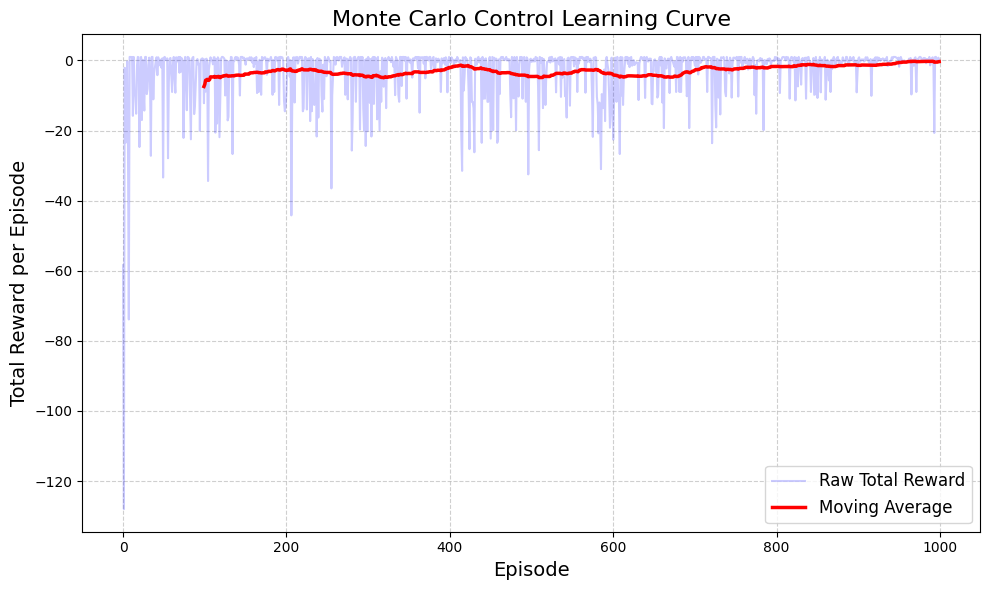

In [27]:
plot_learning_curve(learning_curve, window_size=100)

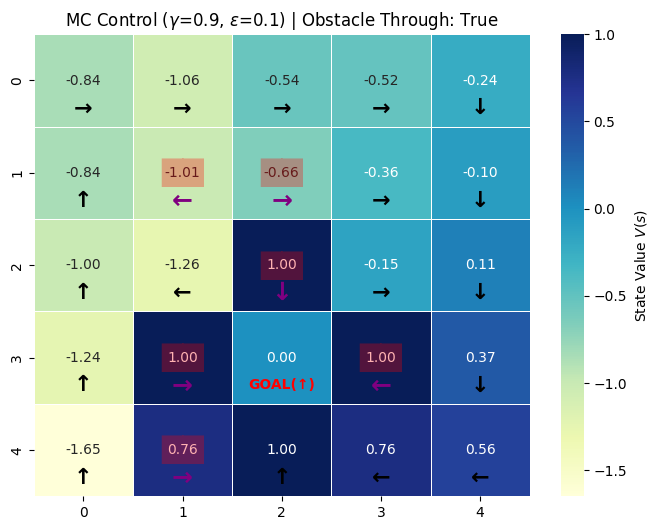

In [28]:
final_policy, final_V = extract_policy(GRID_SIZE, OBSTACLE, Q_final, obstacle_through=obstacle_through)
visualize_grid(final_V, final_policy, Epsilon, OBSTACLE, obstacle_through=obstacle_through)

In [29]:
Q_init_expected_sarsa = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTION)))
Q_final_expected_sarsa, learning_curve_expected_sarsa = Expected_Sarsa(
    Q_init_expected_sarsa, Epsilon, ALPHA, GAMMA, GRID_SIZE, GOAL_STATE, OBSTACLE, max_steps, max_episodes, obstacle_through
    )

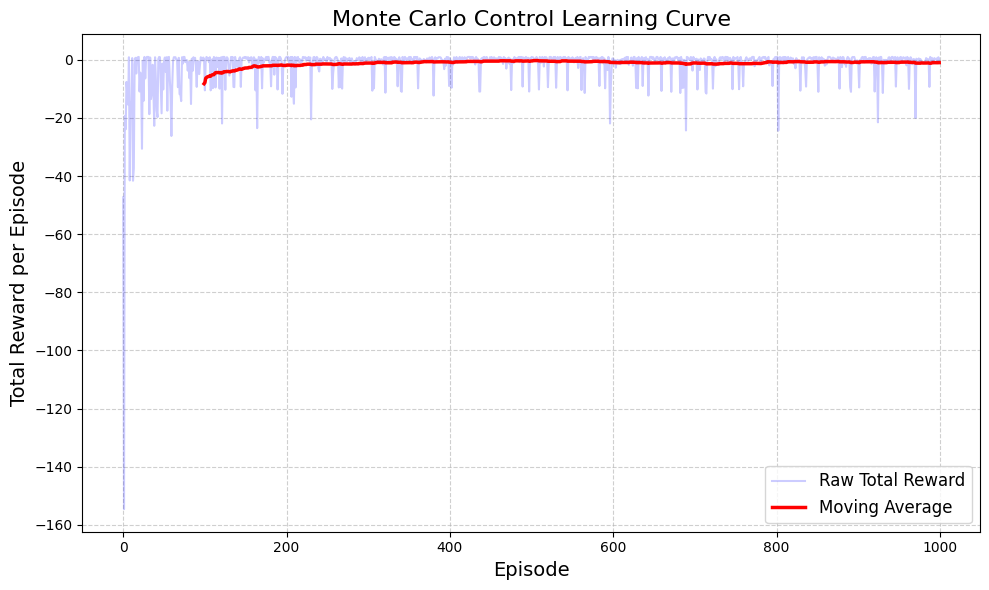

In [30]:
plot_learning_curve(learning_curve_expected_sarsa, window_size=100)

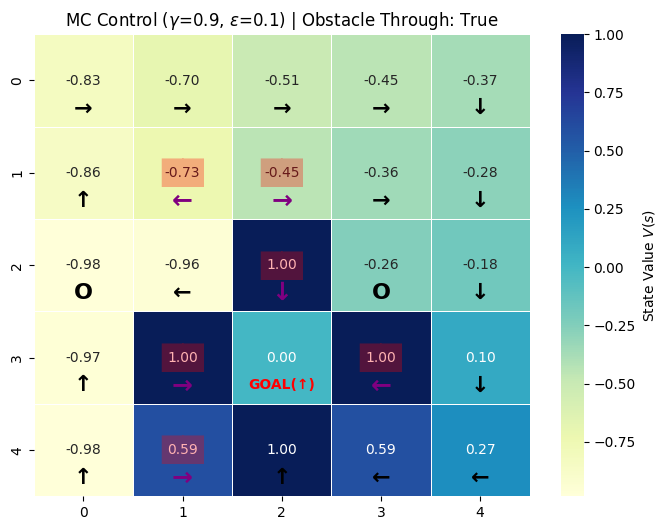

In [31]:
final_policy_expected_sarsa, final_V_expected_sarsa = extract_policy(
    GRID_SIZE, OBSTACLE, Q_final_expected_sarsa, obstacle_through=obstacle_through)
visualize_grid(final_V_expected_sarsa, final_policy_expected_sarsa, Epsilon, OBSTACLE, obstacle_through=obstacle_through)

In [32]:
Q_init_n_step_sarsa = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTION)))
Q_final_n_step_sarsa, learning_curve_n_step_sarsa = n_step_Sarsa(
    Q_init_n_step_sarsa, Epsilon, max_episodes, GRID_SIZE, GOAL_STATE, OBSTACLE, GAMMA, ALPHA, n_steps=3, max_steps=max_steps, obstacle_through=obstacle_through
)

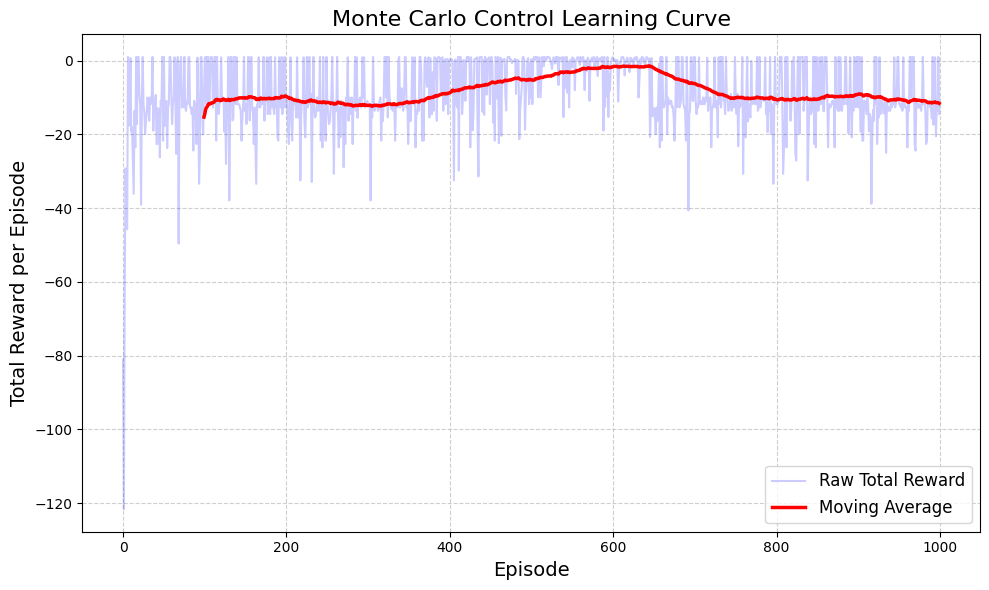

In [33]:
plot_learning_curve(learning_curve_n_step_sarsa, window_size=100)

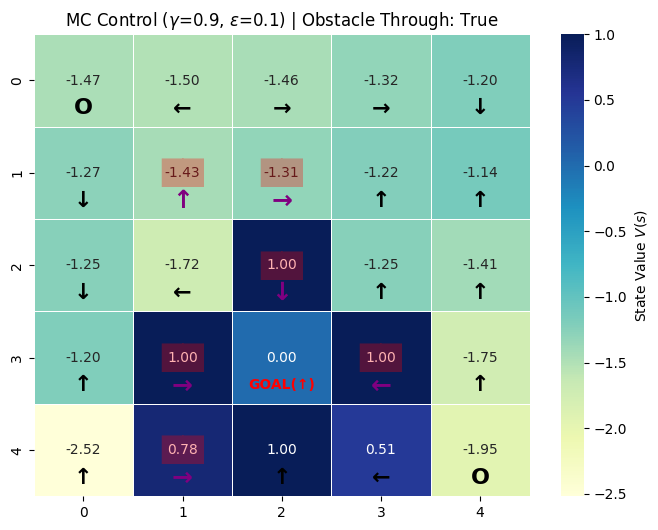

In [34]:
final_policy_n_step_sarsa, final_V_n_step_sarsa = extract_policy(
    GRID_SIZE, OBSTACLE, Q_final_n_step_sarsa, obstacle_through=obstacle_through)
visualize_grid(final_V_n_step_sarsa, final_policy_n_step_sarsa, Epsilon, OBSTACLE, obstacle_through=obstacle_through)